In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


 # All Imports

In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Config (ONE place, never repeat these)

In [3]:
TRAIN_PATH  = "/content/drive/MyDrive/DatasetTrafficSign/Traffic_Sign/Train"
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
VAL_SPLIT   = 0.2
NUM_CLASSES = 4
SEED        = 42
EPOCHS      = 20

print("Path exists:", os.path.exists(TRAIN_PATH))
print("Classes:", sorted(os.listdir(TRAIN_PATH)))

Path exists: True
Classes: ['Caution', 'Instructions', 'No Passing', 'OverSpeed']


# Count Images

In [4]:
print("=" * 40)
total = 0
for cls in sorted(os.listdir(TRAIN_PATH)):
    cls_path = os.path.join(TRAIN_PATH, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        total += count
        print(f"  {cls:<20} {count} images")
print("-" * 40)
print(f"  {'TOTAL':<20} {total} images")

  Caution              2429 images
  Instructions         2848 images
  No Passing           5369 images
  OverSpeed            5249 images
----------------------------------------
  TOTAL                15895 images


#  Bar Chart

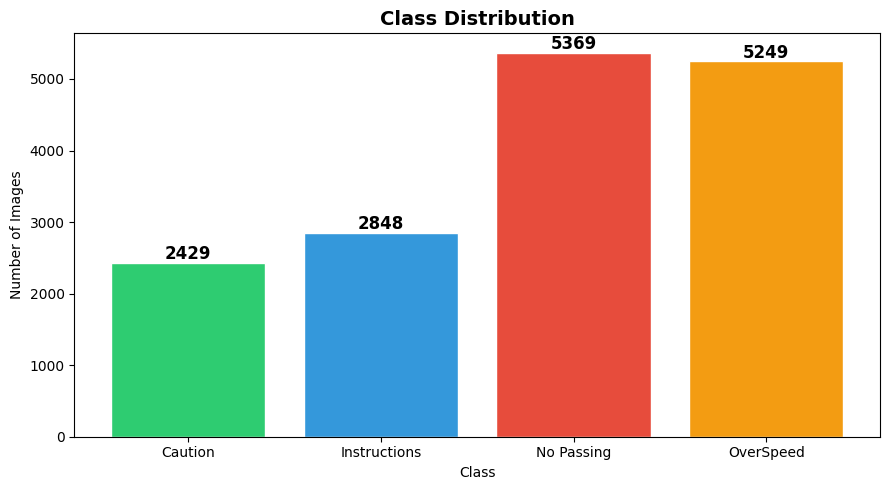

In [5]:
classes, counts = [], []
for cls in sorted(os.listdir(TRAIN_PATH)):
    cls_path = os.path.join(TRAIN_PATH, cls)
    if os.path.isdir(cls_path):
        classes.append(cls)
        counts.append(len(os.listdir(cls_path)))

plt.figure(figsize=(9, 5))
bars = plt.bar(classes, counts,
               color=['#2ecc71','#3498db','#e74c3c','#f39c12'],
               edgecolor='white')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50, str(count),
             ha='center', fontsize=12, fontweight='bold')
plt.title("Class Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Class"); plt.ylabel("Number of Images")
plt.tight_layout(); plt.show()

#  Training Generator

In [6]:
# Training generator — WITH augmentation
train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 10,
    zoom_range         = 0.1,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    horizontal_flip    = True,
    validation_split   = VAL_SPLIT
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    subset      = 'training',
    shuffle     = True,
    seed        = SEED
)

class_names = list(train_generator.class_indices.keys())
print("Classes:", train_generator.class_indices)
print("Training samples:", train_generator.samples)

Found 12719 images belonging to 4 classes.
Classes: {'Caution': 0, 'Instructions': 1, 'No Passing': 2, 'OverSpeed': 3}
Training samples: 12719


#  Validation Generator

In [7]:
# Validation generator — NO augmentation, just rescale
val_datagen = ImageDataGenerator(
    rescale          = 1./255,
    validation_split = VAL_SPLIT
)

val_generator = val_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    subset      = 'validation',
    shuffle     = False,
    seed        = SEED
)

print("Validation samples:", val_generator.samples)

Found 3176 images belonging to 4 classes.
Validation samples: 3176


 # Show Augmented Images

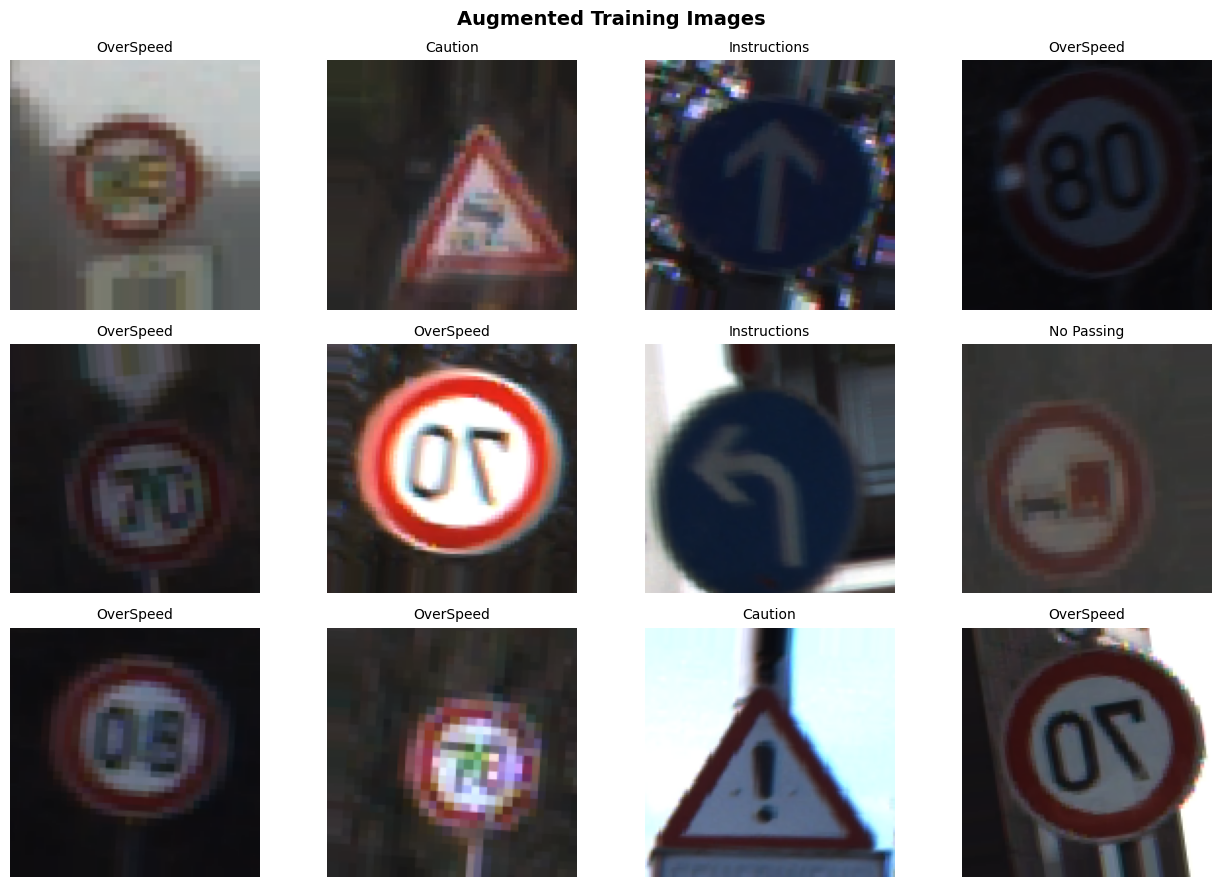

In [8]:
x_batch, y_batch = next(train_generator)

fig, axes = plt.subplots(3, 4, figsize=(13, 9))
fig.suptitle("Augmented Training Images", fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(x_batch[i])
    ax.set_title(class_names[np.argmax(y_batch[i])], fontsize=10)
    ax.axis('off')
plt.tight_layout(); plt.show()

# Build Baseline CNN

In [9]:
baseline_model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),
    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    # Flatten + 3 FC layers
    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),
    # Output
    Dense(NUM_CLASSES, activation='softmax')
], name="Baseline_CNN")

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,557,444 (25.01 MB)

 Trainable params: 6,557,444 (25.01 MB)

 Non-trainable params: 0 (0.00 B)

# Compile

In [10]:
baseline_model.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
print("Compiled ✓")

Compiled ✓


# Find & Remove All Corrupted Images

In [11]:
import os
from PIL import Image

print("Scanning for corrupted images...")
corrupted = []

for cls in sorted(os.listdir(TRAIN_PATH)):
    cls_path = os.path.join(TRAIN_PATH, cls)
    if not os.path.isdir(cls_path):
        continue
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()   # checks file integrity
        except Exception:
            corrupted.append(img_path)

print(f"\nFound {len(corrupted)} corrupted images:")
for p in corrupted:
    print(" ", p)

Scanning for corrupted images...

Found 28 corrupted images:
  /content/drive/MyDrive/DatasetTrafficSign/Traffic_Sign/Train/Caution/00018_00023_00007.png
  /content/drive/MyDrive/DatasetTrafficSign/Traffic_Sign/Train/Caution/00018_00031_00016.png
  /content/drive/MyDrive/DatasetTrafficSign/Traffic_Sign/Train/Caution/00023_00009_00008.png
  /content/drive/MyDrive/DatasetTrafficSign/Traffic_Sign/Train/Caution/00022_00012_00010.png
  /content/drive/MyDrive/DatasetTrafficSign/Traffic_Sign/Train/Caution/00018_00031_00023.png
  /content/drive/MyDrive/DatasetTrafficSign/Traffic_Sign/Train/Caution/00022_00000_00011.png
  /content/drive/MyDrive/DatasetTrafficSign/Traffic_Sign/Train/Caution/00022_00001_00001.png
  /content/drive/MyDrive/DatasetTrafficSign/Traffic_Sign/Train/Instructions/00035_00003_00001.png
  /content/drive/MyDrive/DatasetTrafficSign/Traffic_Sign/Train/Instructions/00028_00001_00009.png
  /content/drive/MyDrive/DatasetTrafficSign/Traffic_Sign/Train/Instructions/00035_00019_0001

# Safe Image Loader (skips corrupted files)

In [13]:
import numpy as np
from PIL import Image
import os

def is_valid_image(filepath):
    try:
        img = Image.open(filepath)
        img.verify()
        return True
    except:
        return False

# Build list of valid files only
valid_files = {cls: [] for cls in sorted(os.listdir(TRAIN_PATH))
               if os.path.isdir(os.path.join(TRAIN_PATH, cls))}

total_valid   = 0
total_corrupt = 0

for cls in valid_files:
    cls_path = os.path.join(TRAIN_PATH, cls)
    for fname in os.listdir(cls_path):
        fpath = os.path.join(cls_path, fname)
        if is_valid_image(fpath):
            valid_files[cls].append(fpath)
            total_valid += 1
        else:
            total_corrupt += 1

print(f"✓ Valid images  : {total_valid}")
print(f"✗ Corrupt images: {total_corrupt} (will be skipped)")
for cls, files in valid_files.items():
    print(f"  {cls:<20} {len(files)} valid images")

✓ Valid images  : 15867
✗ Corrupt images: 28 (will be skipped)
  Caution              2422 valid images
  Instructions         2841 valid images
  No Passing           5362 valid images
  OverSpeed            5242 valid images


# Build Custom Generator (no corrupted files ever loaded)

In [14]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

# ── Flatten all valid paths + labels ─────────────────────────────
all_paths  = []
all_labels = []
class_names = sorted(valid_files.keys())
class_to_idx = {cls: i for i, cls in enumerate(class_names)}

for cls, paths in valid_files.items():
    for p in paths:
        all_paths.append(p)
        all_labels.append(class_to_idx[cls])

print(f"Total valid samples: {len(all_paths)}")
print(f"Classes: {class_to_idx}")

# ── Train / Val split ────────────────────────────────────────────
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels,
    test_size    = 0.2,
    random_state = 42,
    stratify     = all_labels      # keeps class balance
)

print(f"\nTrain samples : {len(train_paths)}")
print(f"Val samples   : {len(val_paths)}")

Total valid samples: 15867
Classes: {'Caution': 0, 'Instructions': 1, 'No Passing': 2, 'OverSpeed': 3}

Train samples : 12693
Val samples   : 3174


# TF Dataset Pipeline (fast, GPU-optimised, no PIL errors)

In [15]:
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
NUM_CLASSES = 4
AUTOTUNE    = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    return img, label

# ── Training dataset ─────────────────────────────────────────────
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)
train_ds = (train_ds
    .shuffle(len(train_paths), seed=42)
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment,             num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ── Validation dataset ───────────────────────────────────────────
val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)
val_ds = (val_ds
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(f"✓ Train batches : {len(train_ds)}")
print(f"✓ Val batches   : {len(val_ds)}")
print("Datasets ready — no corrupted files will be touched")

✓ Train batches : 397
✓ Val batches   : 100
Datasets ready — no corrupted files will be touched


# Train (same as before, now guaranteed no crash)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time

callbacks = [
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 2,
        verbose  = 1,
        min_lr   = 1e-6
    )
]

start = time.time()

baseline_history = baseline_model.fit(
    train_ds,
    epochs          = 20,
    validation_data = val_ds,
    callbacks       = callbacks
)

baseline_time = time.time() - start
print(f"\n✓ Training complete in {baseline_time/60:.1f} min")

Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 76s 170ms/step - accuracy: 0.8596 - loss: 0.3728 - val_accuracy: 0.9342 - val_loss: 0.1722 - learning_rate: 0.0010
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 63s 157ms/step - accuracy: 0.9429 - loss: 0.1628 - val_accuracy: 0.9685 - val_loss: 0.0884 - learning_rate: 0.0010
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 61s 155ms/step - accuracy: 0.9622 - loss: 0.1071 - val_accuracy: 0.9527 - val_loss: 0.1206 - learning_rate: 0.0010
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 60s 152ms/step - accuracy: 0.9698 - loss: 0.0902 - val_accuracy: 0.9713 - val_loss: 0.0693 - learning_rate: 0.0010
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 61s 152ms/step - accuracy: 0.9770 - loss: 0.0676 - val_accuracy: 0.9776 - val_loss: 0.0545 - learning_rate: 0.0010
Epoch 6/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 62s 155ms/step - accuracy: 0.9826 - loss: 0.0520 - val_accuracy: 0.9887 - val_loss: 0.0370 - learning_rate: 0.0010
Epoch 7/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 61s 154ms/step - accuracy: 0.9

# Plot Training Curves

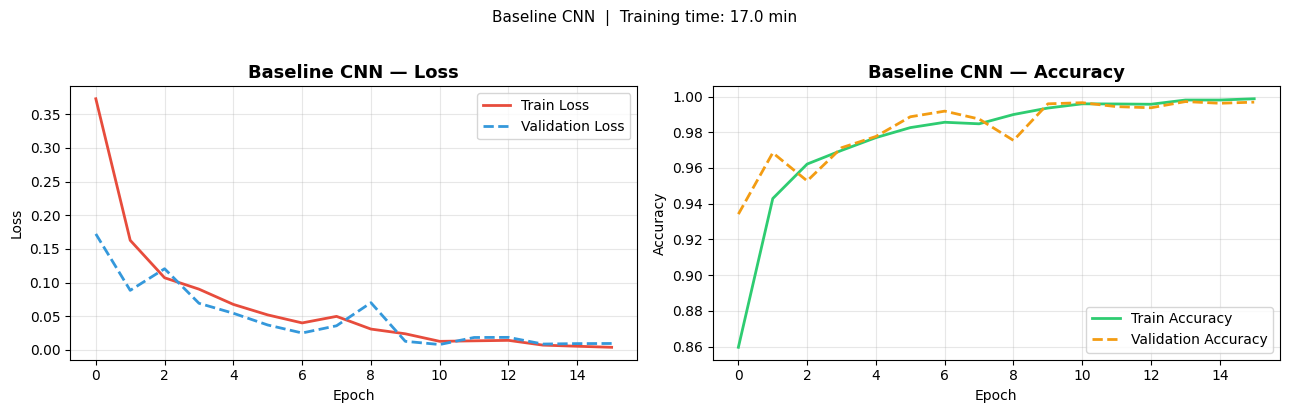

Final Train Accuracy : 0.9987
Final Val Accuracy   : 0.9968
Final Train Loss     : 0.0040
Final Val Loss       : 0.0096


In [17]:
h = baseline_history.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Loss
ax1.plot(h['loss'],     label='Train Loss',      color='#e74c3c', lw=2)
ax1.plot(h['val_loss'], label='Validation Loss', color='#3498db', lw=2, ls='--')
ax1.set_title('Baseline CNN — Loss',     fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

# Accuracy
ax2.plot(h['accuracy'],     label='Train Accuracy',      color='#2ecc71', lw=2)
ax2.plot(h['val_accuracy'], label='Validation Accuracy', color='#f39c12', lw=2, ls='--')
ax2.set_title('Baseline CNN — Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle(f'Baseline CNN  |  Training time: {baseline_time/60:.1f} min',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# Print final numbers
print(f"Final Train Accuracy : {h['accuracy'][-1]:.4f}")
print(f"Final Val Accuracy   : {h['val_accuracy'][-1]:.4f}")
print(f"Final Train Loss     : {h['loss'][-1]:.4f}")
print(f"Final Val Loss       : {h['val_loss'][-1]:.4f}")

# Get All Predictions from Validation Set

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Running predictions on validation set...")

# Collect all true labels and predictions
y_true = []
y_pred = []

for images, labels in val_ds:
    preds  = baseline_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds,   axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(f"✓ Total samples evaluated: {len(y_true)}")

Running predictions on validation set...
✓ Total samples evaluated: 3174


#  Classification Report (Accuracy, Precision, Recall, F1)

In [19]:
print("\n" + "="*55)
print("   BASELINE CNN — CLASSIFICATION REPORT")
print("="*55)
print(classification_report(y_true, y_pred, target_names=class_names))

# Overall accuracy
overall_acc = np.mean(y_true == y_pred)
print(f"Overall Accuracy: {overall_acc:.4f}  ({overall_acc*100:.2f}%)")


   BASELINE CNN — CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Caution       0.99      0.99      0.99       484
Instructions       0.99      1.00      1.00       568
  No Passing       1.00      1.00      1.00      1073
   OverSpeed       1.00      1.00      1.00      1049

    accuracy                           1.00      3174
   macro avg       1.00      1.00      1.00      3174
weighted avg       1.00      1.00      1.00      3174

Overall Accuracy: 0.9965  (99.65%)


# Confusion Matrix

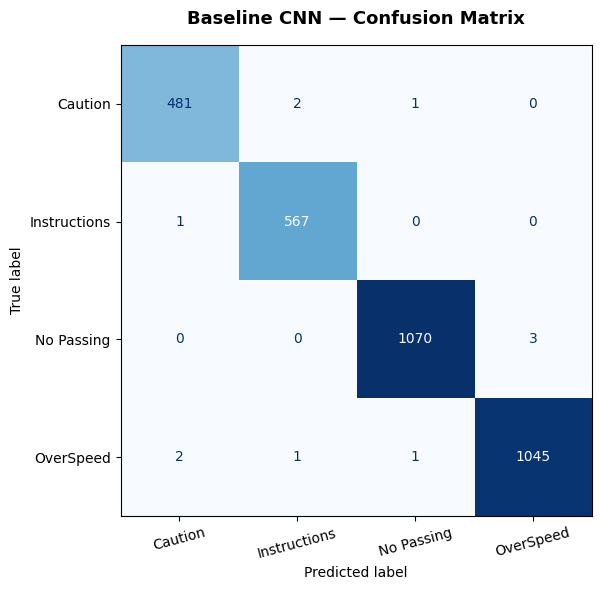


Raw confusion matrix:
                       Caution   Instructions     No Passing      OverSpeed
        Caution            481              2              1              0
   Instructions              1            567              0              0
     No Passing              0              0           1070              3
      OverSpeed              2              1              1           1045


In [20]:
cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Baseline CNN — Confusion Matrix',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# Print raw matrix
print("\nRaw confusion matrix:")
print(f"{'':>15}", end="")
for c in class_names:
    print(f"{c:>15}", end="")
print()
for i, row in enumerate(cm):
    print(f"{class_names[i]:>15}", end="")
    for val in row:
        print(f"{val:>15}", end="")
    print()

# Sample Predictions (Visual)

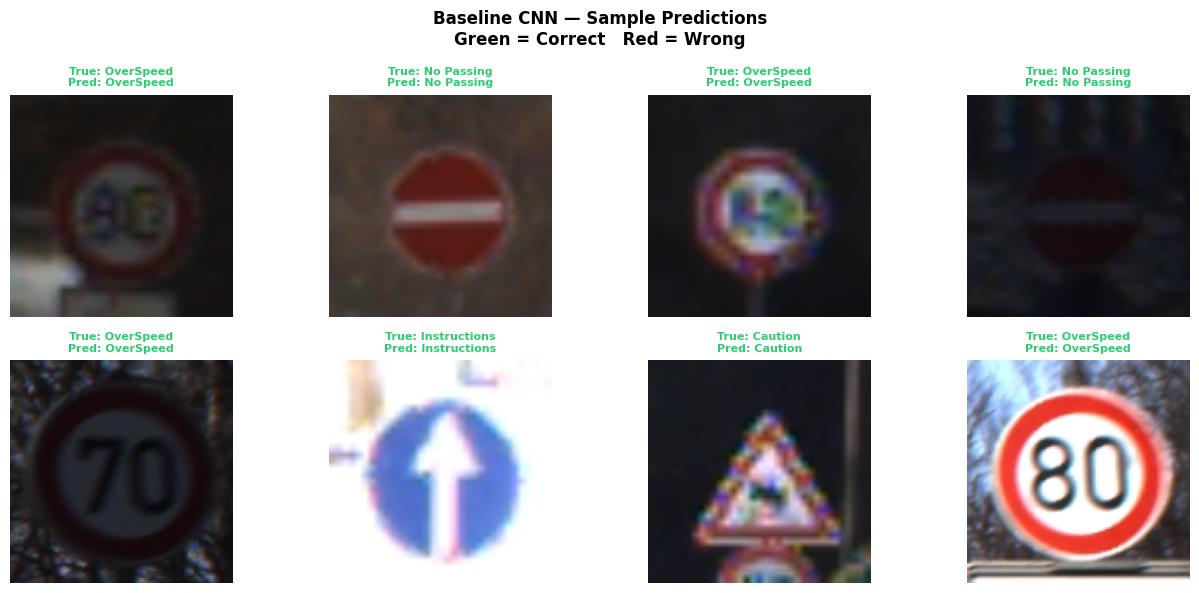

In [21]:
# Grab one batch from validation
sample_images, sample_labels = next(iter(val_ds))
sample_preds = baseline_model.predict(sample_images[:8], verbose=0)

fig, axes = plt.subplots(2, 4, figsize=(13, 6))
fig.suptitle('Baseline CNN — Sample Predictions\n'
             'Green = Correct   Red = Wrong',
             fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i].numpy())
    true_label = class_names[np.argmax(sample_labels[i])]
    pred_label = class_names[np.argmax(sample_preds[i])]
    correct    = true_label == pred_label
    ax.set_title(
        f"True: {true_label}\nPred: {pred_label}",
        color     = '#2ecc71' if correct else '#e74c3c',
        fontsize  = 8,
        fontweight = 'bold'
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

# Save Baseline Results (for comparison later)

In [22]:
# Save these — you will need them when comparing all 3 models
baseline_results = {
    'model'         : 'Baseline CNN',
    'train_acc'     : h['accuracy'][-1],
    'val_acc'       : h['val_accuracy'][-1],
    'train_loss'    : h['loss'][-1],
    'val_loss'      : h['val_loss'][-1],
    'training_time' : baseline_time,
    'epochs_run'    : len(h['accuracy']),
    'y_true'        : y_true,
    'y_pred'        : y_pred
}

print("="*45)
print("  BASELINE CNN — SUMMARY")
print("="*45)
print(f"  Epochs run      : {baseline_results['epochs_run']}")
print(f"  Train Accuracy  : {baseline_results['train_acc']*100:.2f}%")
print(f"  Val Accuracy    : {baseline_results['val_acc']*100:.2f}%")
print(f"  Training Time   : {baseline_results['training_time']/60:.1f} min")
print("="*45)
print("✓ Results saved — ready for comparison with Deep CNN")

  BASELINE CNN — SUMMARY
  Epochs run      : 16
  Train Accuracy  : 99.87%
  Val Accuracy    : 99.68%
  Training Time   : 17.0 min
✓ Results saved — ready for comparison with Deep CNN


# Section 2.5.3 — Deep CNN with Regularization.

#  Build Deep CNN

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                      Dense, Dropout, BatchNormalization)

deep_model = Sequential([

    # ── Block 1 (32 filters) ─────────────────────────
    Conv2D(32, (3,3), activation='relu', padding='same',
           input_shape=(128, 128, 3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # ── Block 2 (64 filters) ─────────────────────────
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # ── Block 3 (128 filters) ────────────────────────
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # ── Block 4 (256 filters) — extra depth ──────────
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.30),

    # ── Fully Connected ───────────────────────────────
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.50),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.40),

    Dense(128, activation='relu'),
    Dropout(0.30),

    # ── Output ───────────────────────────────────────
    Dense(NUM_CLASSES, activation='softmax')

], name="Deep_CNN")

deep_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deep_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,733,028 (37.13 MB)

 Trainable params: 9,729,572 (37.12 MB)

 Non-trainable params: 3,456 (13.50 KB)

#  Train Deep CNN with Adam

In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time

# Compile with Adam first
deep_model.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks = [
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 2,
        verbose  = 1,
        min_lr   = 1e-6
    )
]

print("Training Deep CNN with Adam optimizer...")
start_adam = time.time()

deep_history_adam = deep_model.fit(
    train_ds,
    epochs          = 20,
    validation_data = val_ds,
    callbacks       = callbacks
)

deep_time_adam = time.time() - start_adam
print(f"\n✓ Adam training done in {deep_time_adam/60:.1f} min")

Training Deep CNN with Adam optimizer...
Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 118s 226ms/step - accuracy: 0.7241 - loss: 0.7348 - val_accuracy: 0.5841 - val_loss: 0.9507 - learning_rate: 0.0010
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 64s 161ms/step - accuracy: 0.9062 - loss: 0.2608 - val_accuracy: 0.8900 - val_loss: 0.2664 - learning_rate: 0.0010
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 81s 158ms/step - accuracy: 0.9085 - loss: 0.2630 - val_accuracy: 0.9408 - val_loss: 0.1614 - learning_rate: 0.0010
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 62s 155ms/step - accuracy: 0.9435 - loss: 0.1632 - val_accuracy: 0.9691 - val_loss: 0.0826 - learning_rate: 0.0010
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 71s 180ms/step - accuracy: 0.9477 - loss: 0.1459 - val_accuracy: 0.9701 - val_loss: 0.0740 - learning_rate: 0.0010
Epoch 6/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 71s 153ms/step - accuracy: 0.9465 - loss: 0.1538 - val_accuracy: 0.9660 - val_loss: 0.0897 - learning_rate: 0.0010
Epoch 7/20
397/397 ━━━━━━━━━

#  Plot Deep CNN Adam Curves

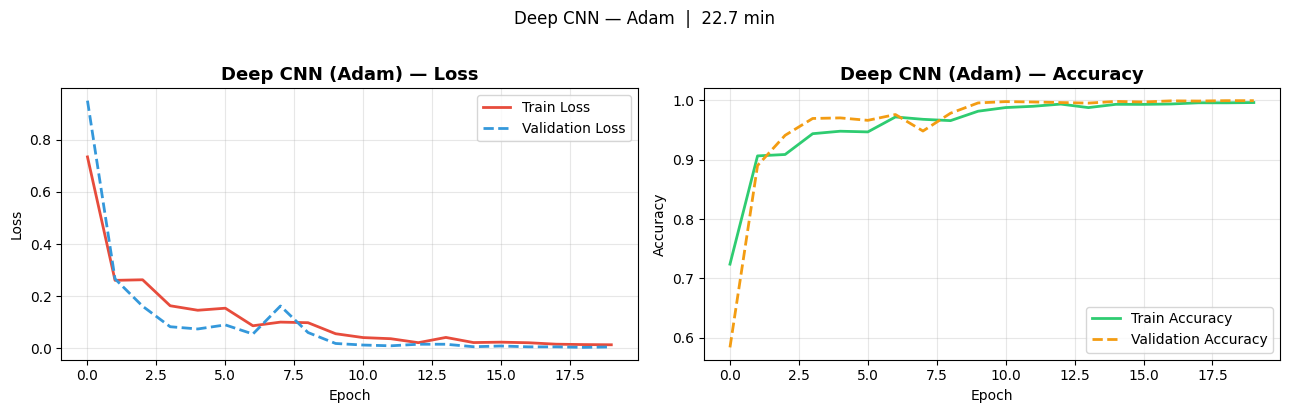

Adam — Final Val Accuracy : 99.91%
Adam — Final Val Loss     : 0.0049


In [25]:
h_adam = deep_history_adam.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(h_adam['loss'],     label='Train Loss',      color='#e74c3c', lw=2)
ax1.plot(h_adam['val_loss'], label='Validation Loss', color='#3498db', lw=2, ls='--')
ax1.set_title('Deep CNN (Adam) — Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(h_adam['accuracy'],     label='Train Accuracy',      color='#2ecc71', lw=2)
ax2.plot(h_adam['val_accuracy'], label='Validation Accuracy', color='#f39c12', lw=2, ls='--')
ax2.set_title('Deep CNN (Adam) — Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle(f'Deep CNN — Adam  |  {deep_time_adam/60:.1f} min', y=1.02)
plt.tight_layout()
plt.show()

print(f"Adam — Final Val Accuracy : {h_adam['val_accuracy'][-1]*100:.2f}%")
print(f"Adam — Final Val Loss     : {h_adam['val_loss'][-1]:.4f}")

# Train Deep CNN with SGD (same model, reset weights)

In [26]:
# Build fresh copy for SGD — same architecture, different optimizer
deep_model_sgd = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2), Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2), Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2), Dropout(0.25),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2), Dropout(0.30),

    Flatten(),
    Dense(512, activation='relu'), BatchNormalization(), Dropout(0.50),
    Dense(256, activation='relu'), BatchNormalization(), Dropout(0.40),
    Dense(128, activation='relu'), Dropout(0.30),
    Dense(NUM_CLASSES, activation='softmax')
], name="Deep_CNN_SGD")

# Compile with SGD
from tensorflow.keras.optimizers import SGD

deep_model_sgd.compile(
    optimizer = SGD(learning_rate=0.01, momentum=0.9),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print("Training Deep CNN with SGD optimizer...")
start_sgd = time.time()

deep_history_sgd = deep_model_sgd.fit(
    train_ds,
    epochs          = 20,
    validation_data = val_ds,
    callbacks       = callbacks
)

deep_time_sgd = time.time() - start_sgd
print(f"\n✓ SGD training done in {deep_time_sgd/60:.1f} min")

Training Deep CNN with SGD optimizer...
Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 94s 186ms/step - accuracy: 0.6438 - loss: 0.8905 - val_accuracy: 0.4764 - val_loss: 1.0859 - learning_rate: 0.0100
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8236 - loss: 0.4660
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
397/397 ━━━━━━━━━━━━━━━━━━━━ 62s 157ms/step - accuracy: 0.8368 - loss: 0.4402 - val_accuracy: 0.8053 - val_loss: 0.6875 - learning_rate: 0.0100
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 64s 160ms/step - accuracy: 0.8889 - loss: 0.3114 - val_accuracy: 0.9260 - val_loss: 0.1867 - learning_rate: 0.0050
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.9122 - loss: 0.2485
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
397/397 ━━━━━━━━━━━━━━━━━━━━ 62s 155ms/step - accuracy: 0.9139 - loss: 0.2429 - val_accuracy: 0.9338 - val_loss: 0.1700 - learning_rate: 0.0050
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━

# SGD vs Adam Comparison Plot

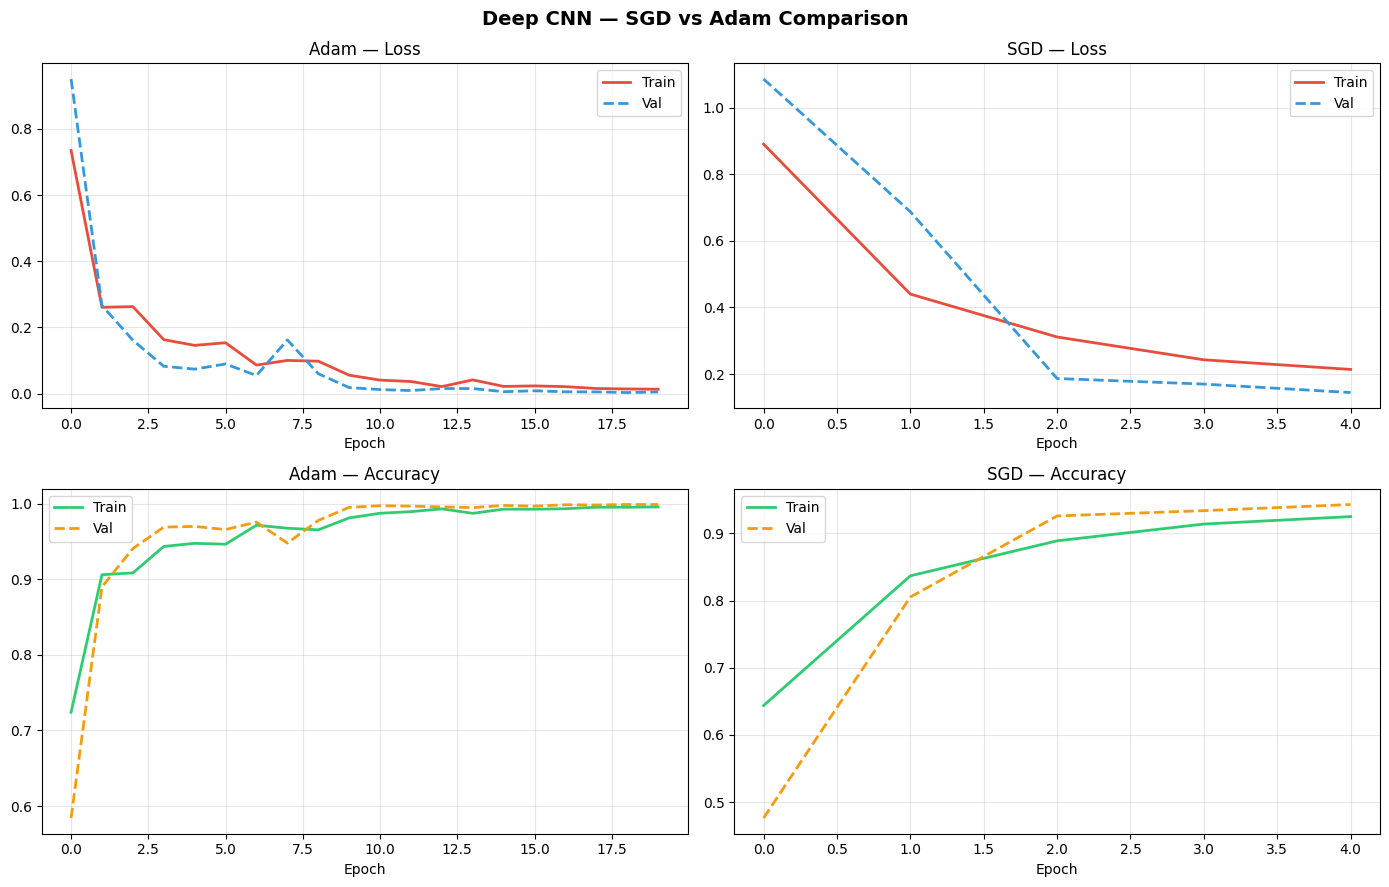

  OPTIMIZER COMPARISON SUMMARY
  Adam — Val Accuracy  : 99.91%
  SGD  — Val Accuracy  : 94.30%
  Adam — Training Time : 22.7 min
  SGD  — Training Time : 6.1 min
  Adam — Epochs run    : 20
  SGD  — Epochs run    : 5


In [27]:
h_sgd = deep_history_sgd.history

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Deep CNN — SGD vs Adam Comparison', fontsize=14, fontweight='bold')

# Top left: Loss - Adam
axes[0,0].plot(h_adam['loss'],     label='Train', color='#e74c3c', lw=2)
axes[0,0].plot(h_adam['val_loss'], label='Val',   color='#3498db', lw=2, ls='--')
axes[0,0].set_title('Adam — Loss'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# Top right: Loss - SGD
axes[0,1].plot(h_sgd['loss'],     label='Train', color='#e74c3c', lw=2)
axes[0,1].plot(h_sgd['val_loss'], label='Val',   color='#3498db', lw=2, ls='--')
axes[0,1].set_title('SGD — Loss'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# Bottom left: Accuracy - Adam
axes[1,0].plot(h_adam['accuracy'],     label='Train', color='#2ecc71', lw=2)
axes[1,0].plot(h_adam['val_accuracy'], label='Val',   color='#f39c12', lw=2, ls='--')
axes[1,0].set_title('Adam — Accuracy'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

# Bottom right: Accuracy - SGD
axes[1,1].plot(h_sgd['accuracy'],     label='Train', color='#2ecc71', lw=2)
axes[1,1].plot(h_sgd['val_accuracy'], label='Val',   color='#f39c12', lw=2, ls='--')
axes[1,1].set_title('SGD — Accuracy'); axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('Epoch'); ax.set_ylabel('')

plt.tight_layout()
plt.show()

# Summary numbers
print("="*50)
print("  OPTIMIZER COMPARISON SUMMARY")
print("="*50)
print(f"  Adam — Val Accuracy  : {h_adam['val_accuracy'][-1]*100:.2f}%")
print(f"  SGD  — Val Accuracy  : {h_sgd['val_accuracy'][-1]*100:.2f}%")
print(f"  Adam — Training Time : {deep_time_adam/60:.1f} min")
print(f"  SGD  — Training Time : {deep_time_sgd/60:.1f} min")
print(f"  Adam — Epochs run    : {len(h_adam['accuracy'])}")
print(f"  SGD  — Epochs run    : {len(h_sgd['accuracy'])}")
print("="*50)

#  Evaluate Deep CNN (Adam — best model)

Evaluating Deep CNN (Adam)...

   DEEP CNN — CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       484
Instructions       1.00      1.00      1.00       568
  No Passing       1.00      1.00      1.00      1073
   OverSpeed       1.00      1.00      1.00      1049

    accuracy                           1.00      3174
   macro avg       1.00      1.00      1.00      3174
weighted avg       1.00      1.00      1.00      3174



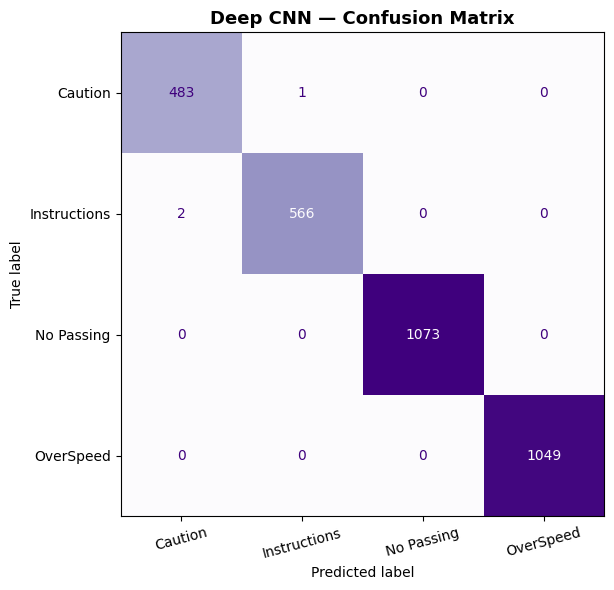

In [28]:
print("Evaluating Deep CNN (Adam)...")

y_true_deep = []
y_pred_deep = []

for images, labels in val_ds:
    preds = deep_model.predict(images, verbose=0)
    y_pred_deep.extend(np.argmax(preds,          axis=1))
    y_true_deep.extend(np.argmax(labels.numpy(), axis=1))

y_true_deep = np.array(y_true_deep)
y_pred_deep = np.array(y_pred_deep)

print("\n" + "="*55)
print("   DEEP CNN — CLASSIFICATION REPORT")
print("="*55)
print(classification_report(y_true_deep, y_pred_deep,
                             target_names=class_names))

# Confusion matrix
cm_deep = confusion_matrix(y_true_deep, y_pred_deep)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm_deep, display_labels=class_names).plot(
    ax=ax, cmap='Purples', colorbar=False)
ax.set_title('Deep CNN — Confusion Matrix', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# Ablation Study (remove Dropout)

In [29]:
# Build same deep architecture but WITHOUT Dropout
ablation_model = Sequential([
    Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    BatchNormalization(),
    Conv2D(32,  (3,3), activation='relu', padding='same'),
    BatchNormalization(), MaxPooling2D(2,2),           # ← no Dropout

    Conv2D(64,  (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64,  (3,3), activation='relu', padding='same'),
    BatchNormalization(), MaxPooling2D(2,2),           # ← no Dropout

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(), MaxPooling2D(2,2),           # ← no Dropout

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(), MaxPooling2D(2,2),           # ← no Dropout

    Flatten(),
    Dense(512, activation='relu'), BatchNormalization(),
    Dense(256, activation='relu'), BatchNormalization(),
    Dense(128, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name="Ablation_No_Dropout")

ablation_model.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print("Training Ablation model (no Dropout)...")
start_abl = time.time()

ablation_history = ablation_model.fit(
    train_ds,
    epochs          = 20,
    validation_data = val_ds,
    callbacks       = callbacks
)

ablation_time = time.time() - start_abl
print(f"\n✓ Ablation training done in {ablation_time/60:.1f} min")

Training Ablation model (no Dropout)...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


397/397 ━━━━━━━━━━━━━━━━━━━━ 86s 180ms/step - accuracy: 0.8440 - loss: 0.4168 - val_accuracy: 0.7936 - val_loss: 0.6361 - learning_rate: 0.0010
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9508 - loss: 0.1339
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
397/397 ━━━━━━━━━━━━━━━━━━━━ 66s 165ms/step - accuracy: 0.9604 - loss: 0.1114 - val_accuracy: 0.9581 - val_loss: 0.1049 - learning_rate: 0.0010
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 73s 184ms/step - accuracy: 0.9869 - loss: 0.0363 - val_accuracy: 0.9937 - val_loss: 0.0197 - learning_rate: 5.0000e-04
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9912 - loss: 0.0268
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
397/397 ━━━━━━━━━━━━━━━━━━━━ 62s 157ms/step - accuracy: 0.9908 - loss: 0.0272 - val_accuracy: 0.9950 - val_loss: 0.0145 - learning_rate: 5.0000e-04
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 62s 155ms/step - accuracy: 0.9948 - l

#  Save All Results + Final Comparison Table

In [30]:
# Save deep results
deep_results = {
    'model'        : 'Deep CNN (Adam)',
    'val_acc'      : h_adam['val_accuracy'][-1],
    'val_loss'     : h_adam['val_loss'][-1],
    'train_acc'    : h_adam['accuracy'][-1],
    'training_time': deep_time_adam,
    'epochs_run'   : len(h_adam['accuracy'])
}

ablation_acc = ablation_history.history['val_accuracy'][-1]
h_abl        = ablation_history.history

print("="*65)
print("  SECTION 2.5.3 — FULL COMPARISON TABLE")
print("="*65)
print(f"{'Model':<28} {'Val Acc':>10} {'Train Acc':>10} {'Time (min)':>12}")
print("-"*65)
print(f"{'Baseline CNN':<28}"
      f" {baseline_results['val_acc']*100:>9.2f}%"
      f" {baseline_results['train_acc']*100:>9.2f}%"
      f" {baseline_results['training_time']/60:>11.1f}")
print(f"{'Deep CNN — Adam':<28}"
      f" {h_adam['val_accuracy'][-1]*100:>9.2f}%"
      f" {h_adam['accuracy'][-1]*100:>9.2f}%"
      f" {deep_time_adam/60:>11.1f}")
print(f"{'Deep CNN — SGD':<28}"
      f" {h_sgd['val_accuracy'][-1]*100:>9.2f}%"
      f" {h_sgd['accuracy'][-1]*100:>9.2f}%"
      f" {deep_time_sgd/60:>11.1f}")
print(f"{'Ablation (no Dropout)':<28}"
      f" {ablation_acc*100:>9.2f}%"
      f" {h_abl['accuracy'][-1]*100:>9.2f}%"
      f" {ablation_time/60:>11.1f}")
print("="*65)
print("\n✓ Section 2.5.3 complete — ready for Transfer Learning (Part B)")

  SECTION 2.5.3 — FULL COMPARISON TABLE
Model                           Val Acc  Train Acc   Time (min)
-----------------------------------------------------------------
Baseline CNN                     99.68%     99.87%        17.0
Deep CNN — Adam                  99.91%     99.59%        22.7
Deep CNN — SGD                   94.30%     92.50%         6.1
Ablation (no Dropout)            99.87%     99.48%         5.8

✓ Section 2.5.3 complete — ready for Transfer Learning (Part B)


# Part B — Section 2.6 Transfer Learning with VGG16

# Build VGG16 Transfer Learning Model

In [31]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense,
                                      Dropout, BatchNormalization)

# Load VGG16 — pretrained on ImageNet, remove top classifier
base_model = VGG16(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (128, 128, 3)
)

# Freeze ALL base layers first (Feature Extraction phase)
base_model.trainable = False

print(f"VGG16 base layers   : {len(base_model.layers)}")
print(f"Trainable params    : {base_model.count_params():,}")
print("All base layers frozen ✓")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 base layers   : 19
Trainable params    : 14,714,688
All base layers frozen ✓


# Add Custom Classification Head

In [32]:
# Add our own top layers for 4-class traffic sign classification
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

# Final model
vgg_model = Model(inputs=base_model.input, outputs=output,
                  name="VGG16_Transfer")

# Count trainable vs frozen
trainable     = sum(1 for l in vgg_model.layers if l.trainable)
non_trainable = sum(1 for l in vgg_model.layers if not l.trainable)

print(f"Total layers        : {len(vgg_model.layers)}")
print(f"Trainable layers    : {trainable}  (our custom head only)")
print(f"Frozen layers       : {non_trainable}  (VGG16 base)")
print()
vgg_model.summary()

Total layers        : 26
Trainable layers    : 7  (our custom head only)
Frozen layers       : 19  (VGG16 base)



Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,89

 Total params: 14,880,452 (56.76 MB)

 Trainable params: 165,252 (645.52 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

#  Phase 1: Feature Extraction (frozen base)

In [33]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time

vgg_model.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks_tl = [
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 2,
        verbose  = 1,
        min_lr   = 1e-7
    )
]

print("Phase 1: Feature Extraction — training top layers only...")
print("Base VGG16 layers are frozen\n")

start_phase1 = time.time()

history_phase1 = vgg_model.fit(
    train_ds,
    epochs          = 10,
    validation_data = val_ds,
    callbacks       = callbacks_tl
)

time_phase1 = time.time() - start_phase1
print(f"\n✓ Phase 1 done in {time_phase1/60:.1f} min")
print(f"  Val Accuracy : {history_phase1.history['val_accuracy'][-1]*100:.2f}%")

Phase 1: Feature Extraction — training top layers only...
Base VGG16 layers are frozen

Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 88s 180ms/step - accuracy: 0.7799 - loss: 0.5386 - val_accuracy: 0.8396 - val_loss: 0.3604 - learning_rate: 0.0010
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 62s 156ms/step - accuracy: 0.8426 - loss: 0.3799 - val_accuracy: 0.8336 - val_loss: 0.3641 - learning_rate: 0.0010
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.8657 - loss: 0.3393
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
397/397 ━━━━━━━━━━━━━━━━━━━━ 64s 161ms/step - accuracy: 0.8639 - loss: 0.3365 - val_accuracy: 0.8321 - val_loss: 0.3785 - learning_rate: 0.0010
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 61s 155ms/step - accuracy: 0.8799 - loss: 0.3000 - val_accuracy: 0.8639 - val_loss: 0.2968 - learning_rate: 5.0000e-04
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 61s 155ms/step - accuracy: 0.8766 - loss: 0.2953 - val_accuracy: 0.8967 - val_loss: 0.2531 - le

# Phase 2: Fine Tuning (unfreeze last VGG16 block)

In [34]:
from tensorflow.keras.optimizers import Adam

# Unfreeze the last convolutional block of VGG16 (block5)
# block5 = last 4 conv layers — layers[-4] onwards in base
base_model.trainable = True

# Freeze everything EXCEPT the last block
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Check what is now trainable
for layer in base_model.layers:
    status = "TRAINABLE" if layer.trainable else "frozen"
    print(f"  {layer.name:<30} {status}")

  input_layer_4                  frozen
  block1_conv1                   frozen
  block1_conv2                   frozen
  block1_pool                    frozen
  block2_conv1                   frozen
  block2_conv2                   frozen
  block2_pool                    frozen
  block3_conv1                   frozen
  block3_conv2                   frozen
  block3_conv3                   frozen
  block3_pool                    frozen
  block4_conv1                   frozen
  block4_conv2                   frozen
  block4_conv3                   frozen
  block4_pool                    frozen
  block5_conv1                   TRAINABLE
  block5_conv2                   TRAINABLE
  block5_conv3                   TRAINABLE
  block5_pool                    TRAINABLE


# Train Phase 2 (fine tuning — low learning rate)

In [35]:
# VERY low learning rate to avoid destroying pretrained weights
vgg_model.compile(
    optimizer = Adam(learning_rate=1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print("Phase 2: Fine Tuning — last VGG16 block + top layers...")
print("Learning rate: 0.00001 (very low to protect pretrained weights)\n")

start_phase2 = time.time()

history_phase2 = vgg_model.fit(
    train_ds,
    epochs          = 10,
    validation_data = val_ds,
    callbacks       = callbacks_tl
)

time_phase2 = time.time() - start_phase2
time_vgg_total = time_phase1 + time_phase2

print(f"\n✓ Phase 2 done in {time_phase2/60:.1f} min")
print(f"  Val Accuracy : {history_phase2.history['val_accuracy'][-1]*100:.2f}%")
print(f"  Total TL time: {time_vgg_total/60:.1f} min")

Phase 2: Fine Tuning — last VGG16 block + top layers...
Learning rate: 0.00001 (very low to protect pretrained weights)

Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 77s 170ms/step - accuracy: 0.9211 - loss: 0.2004 - val_accuracy: 0.9493 - val_loss: 0.1272 - learning_rate: 1.0000e-05
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 62s 155ms/step - accuracy: 0.9505 - loss: 0.1313 - val_accuracy: 0.9549 - val_loss: 0.1026 - learning_rate: 1.0000e-05
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 63s 158ms/step - accuracy: 0.9597 - loss: 0.1059 - val_accuracy: 0.9603 - val_loss: 0.1048 - learning_rate: 1.0000e-05
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 63s 159ms/step - accuracy: 0.9694 - loss: 0.0832 - val_accuracy: 0.9748 - val_loss: 0.0617 - learning_rate: 1.0000e-05
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 62s 156ms/step - accuracy: 0.9711 - loss: 0.0804 - val_accuracy: 0.9757 - val_loss: 0.0595 - learning_rate: 1.0000e-05
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 63s 157ms/step - accuracy: 0.9772 - loss: 0.

# Plot Both Phases Together

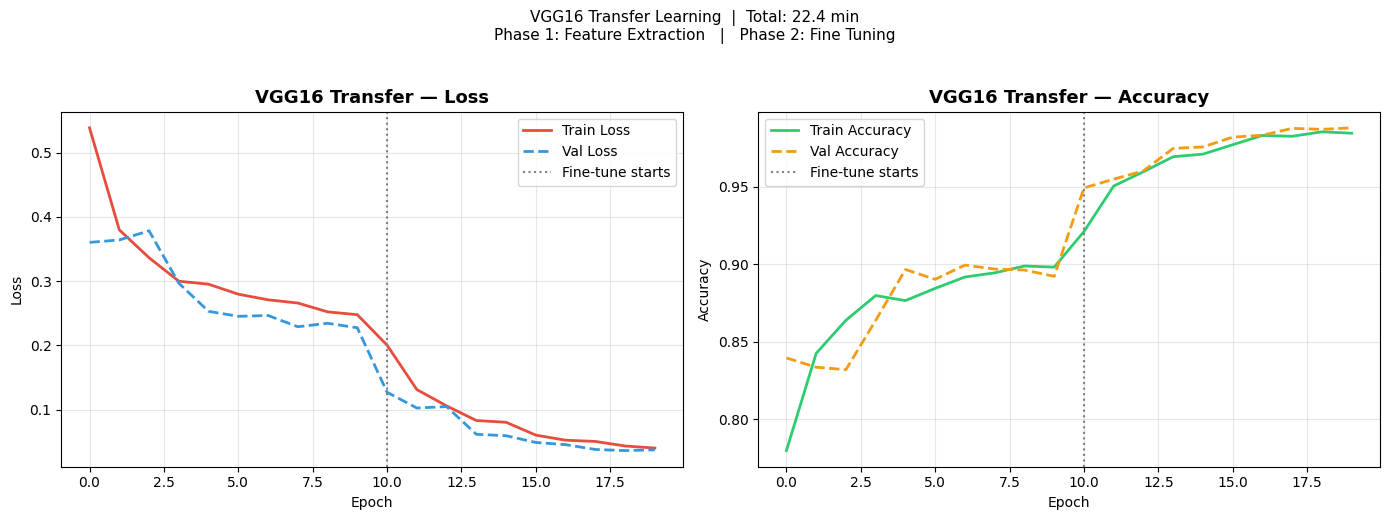

Phase 1 Val Accuracy : 89.22%
Phase 2 Val Accuracy : 98.80%


In [36]:
h1 = history_phase1.history
h2 = history_phase2.history

# Combine both phases for one continuous plot
combined_loss     = h1['loss']     + h2['loss']
combined_val_loss = h1['val_loss'] + h2['val_loss']
combined_acc      = h1['accuracy']     + h2['accuracy']
combined_val_acc  = h1['val_accuracy'] + h2['val_accuracy']

phase1_end = len(h1['loss'])   # where phase 1 ends on x axis

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(combined_loss,     label='Train Loss',      color='#e74c3c', lw=2)
ax1.plot(combined_val_loss, label='Val Loss',        color='#3498db', lw=2, ls='--')
ax1.axvline(x=phase1_end, color='gray', ls=':', lw=1.5, label='Fine-tune starts')
ax1.set_title('VGG16 Transfer — Loss',     fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

# Accuracy
ax2.plot(combined_acc,     label='Train Accuracy',  color='#2ecc71', lw=2)
ax2.plot(combined_val_acc, label='Val Accuracy',    color='#f39c12', lw=2, ls='--')
ax2.axvline(x=phase1_end, color='gray', ls=':', lw=1.5, label='Fine-tune starts')
ax2.set_title('VGG16 Transfer — Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle(f'VGG16 Transfer Learning  |  Total: {time_vgg_total/60:.1f} min\n'
             f'Phase 1: Feature Extraction   |   Phase 2: Fine Tuning',
             fontsize=11, y=1.03)
plt.tight_layout()
plt.show()

print(f"Phase 1 Val Accuracy : {h1['val_accuracy'][-1]*100:.2f}%")
print(f"Phase 2 Val Accuracy : {h2['val_accuracy'][-1]*100:.2f}%")

#  Evaluate VGG16

Evaluating VGG16 Transfer Learning model...

   VGG16 TRANSFER — CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Caution       0.99      0.99      0.99       484
Instructions       1.00      0.99      1.00       568
  No Passing       0.97      1.00      0.98      1073
   OverSpeed       1.00      0.97      0.98      1049

    accuracy                           0.99      3174
   macro avg       0.99      0.99      0.99      3174
weighted avg       0.99      0.99      0.99      3174



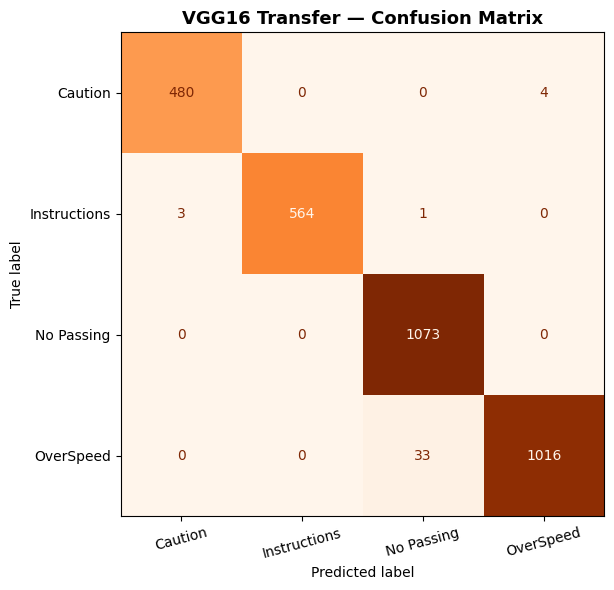

In [37]:
print("Evaluating VGG16 Transfer Learning model...")

y_true_vgg = []
y_pred_vgg = []

for images, labels in val_ds:
    preds = vgg_model.predict(images, verbose=0)
    y_pred_vgg.extend(np.argmax(preds,          axis=1))
    y_true_vgg.extend(np.argmax(labels.numpy(), axis=1))

y_true_vgg = np.array(y_true_vgg)
y_pred_vgg = np.array(y_pred_vgg)

print("\n" + "="*55)
print("   VGG16 TRANSFER — CLASSIFICATION REPORT")
print("="*55)
print(classification_report(y_true_vgg, y_pred_vgg,
                             target_names=class_names))

# Confusion matrix
cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm_vgg, display_labels=class_names).plot(
    ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('VGG16 Transfer — Confusion Matrix',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# Sample Predictions VGG16

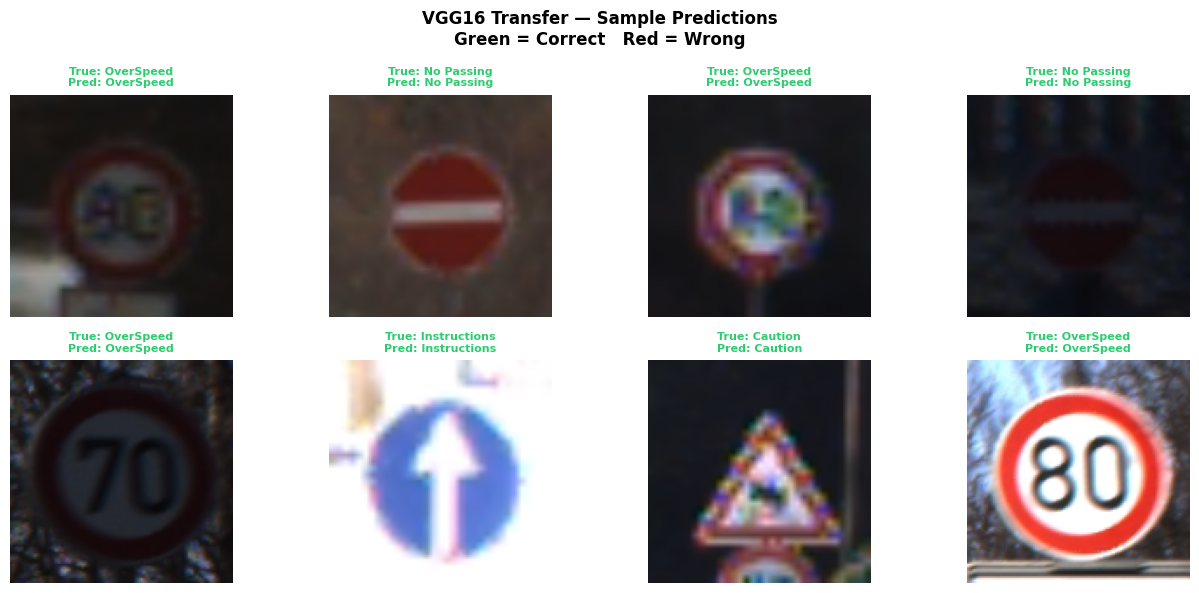

In [38]:
sample_images, sample_labels = next(iter(val_ds))
sample_preds_vgg = vgg_model.predict(sample_images[:8], verbose=0)

fig, axes = plt.subplots(2, 4, figsize=(13, 6))
fig.suptitle('VGG16 Transfer — Sample Predictions\n'
             'Green = Correct   Red = Wrong',
             fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i].numpy())
    true_label = class_names[np.argmax(sample_labels[i])]
    pred_label = class_names[np.argmax(sample_preds_vgg[i])]
    correct    = true_label == pred_label
    ax.set_title(
        f"True: {true_label}\nPred: {pred_label}",
        color      = '#2ecc71' if correct else '#e74c3c',
        fontsize   = 8,
        fontweight = 'bold'
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

#  Final 3-Way Comparison Table (All Models)


In [39]:
vgg_val_acc   = history_phase2.history['val_accuracy'][-1]
vgg_train_acc = history_phase2.history['accuracy'][-1]

print("="*70)
print("   FINAL COMPARISON — ALL MODELS")
print("="*70)
print(f"{'Model':<28} {'Val Acc':>10} {'Train Acc':>10} {'Time (min)':>12}")
print("-"*70)
print(f"{'Baseline CNN':<28}"
      f" {baseline_results['val_acc']*100:>9.2f}%"
      f" {baseline_results['train_acc']*100:>9.2f}%"
      f" {baseline_results['training_time']/60:>11.1f}")
print(f"{'Deep CNN — Adam':<28}"
      f" {h_adam['val_accuracy'][-1]*100:>9.2f}%"
      f" {h_adam['accuracy'][-1]*100:>9.2f}%"
      f" {deep_time_adam/60:>11.1f}")
print(f"{'Deep CNN — SGD':<28}"
      f" {h_sgd['val_accuracy'][-1]*100:>9.2f}%"
      f" {h_sgd['accuracy'][-1]*100:>9.2f}%"
      f" {deep_time_sgd/60:>11.1f}")
print(f"{'Ablation (no Dropout)':<28}"
      f" {ablation_history.history['val_accuracy'][-1]*100:>9.2f}%"
      f" {ablation_history.history['accuracy'][-1]*100:>9.2f}%"
      f" {ablation_time/60:>11.1f}")
print(f"{'VGG16 Transfer Learning':<28}"
      f" {vgg_val_acc*100:>9.2f}%"
      f" {vgg_train_acc*100:>9.2f}%"
      f" {time_vgg_total/60:>11.1f}")
print("="*70)
print("\n✓ Part A + Part B fully complete!")
print("✓ All models trained, evaluated and compared")
print("✓ Ready to write the final report")

   FINAL COMPARISON — ALL MODELS
Model                           Val Acc  Train Acc   Time (min)
----------------------------------------------------------------------
Baseline CNN                     99.68%     99.87%        17.0
Deep CNN — Adam                  99.91%     99.59%        22.7
Deep CNN — SGD                   94.30%     92.50%         6.1
Ablation (no Dropout)            99.87%     99.48%         5.8
VGG16 Transfer Learning          98.80%     98.46%        22.4

✓ Part A + Part B fully complete!
✓ All models trained, evaluated and compared
✓ Ready to write the final report
